In [13]:
# Suppress Warning messages
import warnings
warnings.simplefilter(action='ignore')

In [14]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [15]:
PROBLEM_NAME = 'ContinuousPeaks'

# PARAM_NAME = 'Max Restarts'
# PARAM_KEY = 'max_restarts'
# ALGORITHM_NAME = 'RHC'

PARAM_NAME = 'Start Temperature'
PARAM_KEY = 'start_temperature'
ALGORITHM_NAME = 'SA'

# PARAM_NAME = 'Keep Percent'
# PARAM_KEY = 'keep_percent'
# ALGORITHM_NAME = 'MIMIC'

In [16]:
out_dir = f'learning_curves'
os.makedirs(out_dir, exist_ok=True)

In [17]:
# all_df = pd.read_csv(f'metrics/{PROBLEM_NAME}_500_{ALGORITHM_NAME}_small/learning_curve.csv')
all_df = pd.read_csv(f'metrics/{PROBLEM_NAME}_500_{ALGORITHM_NAME}/learning_curve.csv')

5
10001


10001it [00:17, 558.30it/s]


10001


10001it [00:15, 650.31it/s]


10001


10001it [00:14, 682.84it/s]


10001


10001it [00:15, 660.36it/s]


10001


10001it [00:25, 391.00it/s]


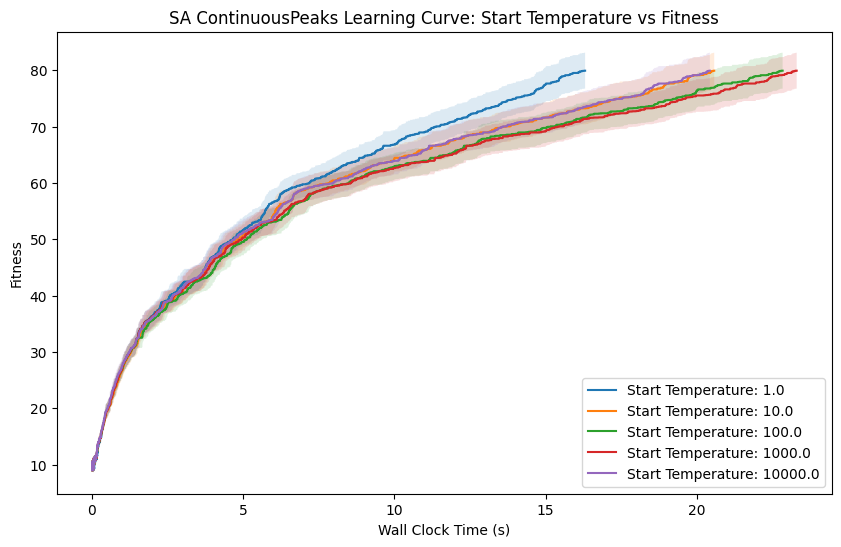

In [18]:
EXTEND = False
plt.figure(figsize=(10, 6))
max_time = all_df['Time'].max()
param_values = all_df[PARAM_KEY].unique()
print(len(param_values))
for param_value in param_values:
    df = all_df[all_df[PARAM_KEY] == param_value]
    run_num = df['run_number'].unique()[0]
    run_df = df[df['run_number'] == run_num]
    print(len(run_df))
    for i, row in tqdm(run_df.iterrows()):
        s_df = all_df[all_df['Iteration'] == row['Iteration']]
        run_df.loc[i, 'fitness_mean'] = s_df['Fitness'].mean()
        run_df.loc[i, 'fitness_std'] = s_df['Fitness'].std()
    run_df = run_df.sort_values('Time')
    run_df = run_df.iloc[1:]
    X = np.array(run_df['Time'])
    y = np.array(run_df['fitness_mean'])
    y_error = np.array(run_df['fitness_std'])

    if EXTEND:
        y = np.append(y, y[-1])
        X = np.append(X, max_time)
        y_error = np.append(y_error, y_error[-1])

    y_error = y_error / 5
    plt.plot(X, y, label=f"{PARAM_NAME}: {param_value}")
    plt.fill_between(X, y-y_error, y+y_error, alpha=0.15)
# set xlabel to Wall Clock Time (s) 
plt.xlabel('Wall Clock Time (s)')
plt.ylabel('Fitness')
# set legend position to bottom right
plt.legend(loc='lower right')
plt.title(f'{ALGORITHM_NAME} {PROBLEM_NAME} Learning Curve: {PARAM_NAME} vs Fitness'.format(PARAM_NAME))

save_path = os.path.join(out_dir, f"{ALGORITHM_NAME}_{PROBLEM_NAME}_{PARAM_NAME}_vs_Fitness.png") 
plt.savefig(save_path)